# Utils

In [127]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/user1/WhatDoLLMsWant


In [128]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator

from src.bt import FeatureBT

BASES = ["data/laptops_robustness", "data/laptops_robustness_gemma", "data/laptops_olmo"]
FRAME, EXPECT = "shopping", 9900
FIGDIR = "figs/summary"

BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SCREEN, RAM = ["13-inch", "14-inch", "16-inch"], ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SCREEN, "ram": RAM}
LAPTOPS = [(b, s, r) for b in BRANDS for s in SCREEN for r in RAM]
LAP_INDEX = pd.MultiIndex.from_tuples(LAPTOPS, names=["brand", "screen", "ram"])

# One colour per feature: screen pink, RAM blue, brand green (chosen by Lotan, 2026-10-08).
# Every colour the figure uses. These are the defaults; the arguments cell passes its own
# COLORS to make_summary, which calls set_colors().
DEFAULT_COLORS = {
    "screen": "#e87ba4",        # pink: feature colour, and "meets the screen requirement"
    "ram": "#7BA4E8",           # blue: feature colour, and "meets the RAM requirement"
    "brand": "#A4E87B",         # green: feature colour, and Apple's line in panel 5
    "both": "#4a3aa7",          # panels 2-3: meets both requirements
    "none": "#c9c8c4",          # panels 2-3: meets none
    "gamma": "#0b0b0b",         # panel 4: the positional-bias bar
    "full_bt": "#2a78d6",       # panel 1: fully parametrised BT
    "linear_bt": "#eb6834",     # panel 1: linear (additive) BT
    "other_brands": "#7f8fa6",  # panel 5: the four brands that are not Apple
}
COL, FEATURE_COLOR, MIX, BT_COLOR = {}, {}, {}, {}


def set_colors(colors=None):
    """Fill the colour tables from DEFAULT_COLORS overridden by `colors` (missing keys keep the default)."""
    COL.clear(); COL.update(DEFAULT_COLORS, **(colors or {}))
    FEATURE_COLOR.clear(); FEATURE_COLOR.update({f: COL[f] for f in ("brand", "screen", "ram")})
    MIX.clear(); MIX.update({frozenset(): COL["none"], frozenset({"screen"}): COL["screen"],
                             frozenset({"ram"}): COL["ram"], frozenset({"screen", "ram"}): COL["both"]})
    BT_COLOR.clear(); BT_COLOR.update({"full": COL["full_bt"], "additive": COL["linear_bt"]})


set_colors()
APPLE_LS = (0, (4, 2))
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})


def name(m):
    return f"{m[0]}-{m[1]}B"


def short(key):
    *b, s, r = key
    return " ".join(b + [s.replace("-inch", "in"), r])

## Building blocks: data and fits

In [129]:
def load_runs(model, contracts):
    """{constraints_id: scores DataFrame} for one model. Complete runs only, frame pinned,
    one run per contract (asserted). Contracts with no run are simply absent."""
    R = {}
    for base in BASES:
        for run in sorted(os.listdir(base)):
            cf, sc = (os.path.join(base, run, f) for f in ("config.json", "scores.csv"))
            if not (os.path.isfile(cf) and os.path.isfile(sc)):
                continue
            c = json.load(open(cf))
            if ((c["model_family"], str(c["model_size"])) != model or c["frame"]["name"] != FRAME
                    or c["constraints_id"] not in contracts):
                continue
            d = pd.read_csv(sc)
            if len(d) != EXPECT:
                continue
            assert c["constraints_id"] not in R, f"two complete runs for {model} {c['constraints_id']}"
            R[c["constraints_id"]] = d
    return R


def pmi_c(d, tol=0.01, min_sat=0.01):
    """The PMI constant C of ONE run. PMI off => every stored score <= 0 => C = 0.
    PMI on => recovered from saturation; NaN if the model never saturates."""
    if max(d.score_a.max(), d.score_b.max()) <= 1e-9:
        return 0.0
    mA, mB = d.score_a.max(), d.score_b.max()
    sat = min((d.score_a > mA - tol).mean(), (d.score_b > mB - tol).mean())
    return mB - mA if sat >= min_sat else np.nan


def feature_fit(d):
    """Additive BT (FeatureBT) with gamma corrected by this run's own C."""
    return FeatureBT(pmi_c=pmi_c(d), r2_warn=None).fit(d)


def additive_utility(fit):
    return pd.Series([fit.utility(dict(brand=b, screen=s, ram=r)) for b, s, r in LAPTOPS], index=LAP_INDEX)


def item_utility(d):
    """Full parametrization: one free utility per laptop (OLS on the margins), centred."""
    idx = {l: i for i, l in enumerate(LAPTOPS)}
    a = np.array([idx[t] for t in zip(d.a_brand, d.a_screen, d.a_ram)])
    b = np.array([idx[t] for t in zip(d.b_brand, d.b_screen, d.b_ram)])
    n = len(d)
    X = np.zeros((n, len(LAPTOPS)))
    X[np.arange(n), a] += 1
    X[np.arange(n), b] -= 1
    X = np.column_stack([np.ones(n), X[:, 1:]])
    beta = np.linalg.lstsq(X, (d.score_a - d.score_b).values, rcond=None)[0]
    u = np.r_[0.0, beta[1:]]
    return pd.Series(u - u.mean(), index=LAP_INDEX)


def duel(d):
    """D[x, y]: x's margin over y averaged over both slot orders and the templates.
    The positional bias cancels in the average."""
    t = pd.DataFrame({"A": list(zip(d.a_brand, d.a_screen, d.a_ram)),
                      "B": list(zip(d.b_brand, d.b_screen, d.b_ram)),
                      "m": (d.score_a - d.score_b).values})
    M = t.groupby(["A", "B"])["m"].mean().unstack().reindex(index=LAPTOPS, columns=LAPTOPS)
    return (M - M.T) / 2


def borda(d):
    """Position-corrected Borda score: rivals beaten with D > 0 (out of 44)."""
    return pd.Series((duel(d) > 0).sum(axis=1).values, index=LAP_INDEX).astype(float)


def rank_desc(x, ties="first"):
    return pd.Series(x).rank(ascending=False, method=ties)


def laptop_ranks(d, fit, rank_by):
    """1 = most preferred. rank_by = "utility" (additive BT) or "wins" (head-to-head, ties by margin)."""
    if rank_by == "utility":
        return rank_desc(additive_utility(fit).values).values
    D = duel(d)
    key = pd.DataFrame({"wins": (D > 0).sum(axis=1), "margin": D.mean(axis=1)})
    order = key.sort_values(["wins", "margin"], ascending=False).index
    return pd.Series(np.arange(1, 46), index=order).reindex(LAPTOPS).values


def make_path(ids, label=None):
    """A contract path: each contract as {feature: level}, and labels written in the order the
    path adds requirements."""
    cons = [dict(p.split("=") for p in c.split("+")) if c != "none" else {} for c in ids]
    order = []
    for con in cons:      # features in the order the path adds them; ties in a fixed order
        order += sorted(set(con) - set(order), key=["screen", "ram", "brand"].index)
    lab = [" + ".join(con[f] for f in order if f in con) or "no contract" for con in cons]
    return dict(ids=ids, cons=cons, order=order, lab=lab, label=label or " → ".join(lab))


def met(lvl, con):
    return frozenset(f for f, v in con.items() if lvl.get(f) == v)

## Building blocks: the panels

Every panel function takes its title, axis labels and legend texts as arguments, so the
arguments cell controls all visible text. Font sizes scale with `FONT_SIZE`.

In [130]:
FS = {"base": 10}                    # set by make_summary from FONT_SIZE


def fs(k):
    """A size relative to the base font size (k = size at base 10)."""
    return FS["base"] * k / 10


def contract_label(cid, names):
    """'ram=8GB+screen=14-inch' -> '14"+8GB' using the arguments' names, screen before RAM."""
    if cid == "none":
        return names["none"]
    con = dict(p.split("=") for p in cid.split("+"))
    return "+".join(names.get(con[f], con[f]) for f in ("screen", "ram", "brand") if f in con)


def missing(ax, what):
    ax.text(0.5, 0.5, f"no run for\n{what}", transform=ax.transAxes, ha="center", va="center",
            color=INK_MUTED, fontsize=fs(11))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)


def style(ax, xlabel, ylabel, x_between=False, y_between=True):
    """Axis labels and tick sizes. y_between / x_between: put the axis label BETWEEN the two end
    ticks, level with the tick labels, instead of outside them."""
    ax.tick_params(labelsize=fs(8.5), length=fs(3.5), pad=fs(3))
    off = (fs(3.5) + fs(3)) / 72                          # tick length + pad, in inches
    ax.set_xlabel(xlabel, fontsize=fs(9.5))
    ax.set_ylabel(ylabel, fontsize=fs(9.5))
    if y_between:
        ax.yaxis.set_label_coords(0, 0.5, transform=ax.transAxes + mtrans.ScaledTranslation(-off, 0, ax.figure.dpi_scale_trans))
    if x_between:
        ax.xaxis.set_label_coords(0.5, 0, transform=ax.transAxes + mtrans.ScaledTranslation(0, -off, ax.figure.dpi_scale_trans))


def wrap_to_fit(t, room_px, renderer):
    """Word-wrap text `t` so no line is longer than `room_px` (along the text's own direction).
    A lone "-" stays at the end of the word before it ("Feature Weights -" / "Default").
    Always re-wraps from the original one-line text, so it can be called again after a layout change."""
    orig = getattr(t, "_orig_text", None) or t.get_text().replace("\n", " ")
    t._orig_text = orig
    words = []
    for w in orig.split(" "):
        if w == "-" and words:
            words[-1] += " -"
        elif w:
            words.append(w)
    if len(words) < 2:
        return

    def length(s):
        t.set_text(s)
        e = t.get_window_extent(renderer)
        return e.height if t.get_rotation() % 180 == 90 else e.width

    lines, line = [], ""
    for w in words:
        cand = f"{line} {w}".strip()
        if line and length(cand) > room_px:
            lines.append(line)
            line = w
        else:
            line = cand
    lines.append(line)
    t.set_text("\n".join(lines))


def fit_texts(fig, axes):
    """Wrap every panel title, and every between-the-ticks axis label, to the room it has; then
    top-align the titles so their first lines sit at the same height.

    A centred title may run past its panel's edges into the empty space between panels, up to
    the neighbouring plot (or the figure edge); it wraps only if it does not fit even there."""
    for _ in range(2):                         # layout moves after wrapping: settle, then check again
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        for k, ax in enumerate(axes):
            box = ax.get_window_extent(r)
            left = axes[k - 1].get_window_extent(r).x1 if k else fig.bbox.x0
            right = axes[k + 1].get_window_extent(r).x0 if k + 1 < len(axes) else fig.bbox.x1
            cx = (box.x0 + box.x1) / 2
            room = 2 * min(cx - left, right - cx) - fs(8) / 72 * fig.dpi   # keep a small margin
            wrap_to_fit(ax.title, room, r)
            for axis, along in ((ax.yaxis, "y"), (ax.xaxis, "x")):
                ticks = [t for t in axis.get_ticklabels() if t.get_text()]
                if len(ticks) != 2 or not axis.label.get_text():
                    continue
                b = sorted((t.get_window_extent(r) for t in ticks), key=lambda e: e.y0 if along == "y" else e.x0)
                room = (b[1].y0 - b[0].y1) if along == "y" else (b[1].x0 - b[0].x1)
                wrap_to_fit(axis.label, room - fs(4), r)
    align_titles(fig, axes)


def align_titles(fig, axes):
    """Top-align the centred titles: every first line at the same height above its panel."""
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    tall = max(ax.title.get_window_extent(r).height for ax in axes if ax.title.get_text())
    pad = fs(6) / 72 * fig.dpi
    for ax in axes:
        t = ax.title
        if not t.get_text():
            continue
        ax._autotitlepos = False                # keep matplotlib from moving it back
        t.set_verticalalignment("top")
        t.set_y(1 + (pad + tall) / ax.get_window_extent(r).height)


def ends_only(ax):
    """Numeric y-axis: round the limits outward to clean values and tick only those two ends."""
    lo, hi = ax.get_ylim()
    t = MaxNLocator(nbins=10, steps=[1, 2, 2.5, 5, 10]).tick_values(lo, hi)   # fine steps: ends hug the data
    a, b = max(v for v in t if v <= lo + 1e-12), min(v for v in t if v >= hi - 1e-12)
    ax.set_ylim(a, b)
    ax.set_yticks([a, b])


def panel_borda(ax, d, fit, xlabel, ylabel, legend, rank_ticks=("high", "low"), tick_angle=30):
    """1. x = position-corrected Borda rank, y = BT rank, full and additive (linear) fit.
    Both axes: rank 1 = "high", rank 45 = "low"; the axis labels sit between the two ticks."""
    bs = borda(d)
    xr = rank_desc(bs.values, ties="average")
    ax.plot([0.5, 45.5], [0.5, 45.5], color="#d6d5d1", lw=fs(1), zorder=1)
    rho = {}
    for k, (lab, u, mk) in enumerate([("full", item_utility(d), "o"), ("additive", additive_utility(fit), "^")]):
        rho[lab] = st.spearmanr(bs.values, u.values)[0]      # Spearman(Borda score, BT utility)
        ax.scatter(xr, rank_desc(u.values), s=fs(22), color=BT_COLOR[lab], marker=mk, edgecolor=SURFACE,
                   lw=fs(0.4), zorder=2, alpha=0.9,
                   label=f"{legend[k]} (ρ={rho[lab]:.3f})" if legend else None)
    ax.set_xlim(0.5, 45.5); ax.set_ylim(45.5, 0.5)
    ax.set_xticks([1, 45], list(rank_ticks), rotation=tick_angle, ha="right" if tick_angle else "center", rotation_mode="anchor" if tick_angle else "default")
    ax.set_yticks([1, 45], list(rank_ticks))
    style(ax, xlabel, ylabel, x_between=True)
    if legend:
        # lower left is empty: the points run along the diagonal from top left to bottom right
        ax.legend(loc="lower left", frameon=True, framealpha=0.6, facecolor=SURFACE, edgecolor="none",
                  fontsize=fs(6.5), handletextpad=0.1, borderaxespad=0.2,
                  markerscale=0.8, labelspacing=0.3)
    return rho


def panel_paths(ax, R, path_a, path_b, xlabel, ylabel, legend, names, labels=False,
                rank_ticks=("high", "low"), missing_b=None, flow_gap=0.6, tick_angle=30):
    """2. Two flows side by side in ONE plot: path_a (e.g. default -> 14" -> 14"+8GB), then, after
    a gap of `flow_gap` x-units, path_b (e.g. default -> 4GB). y = rank (1 on top). A segment is
    coloured by the requirements of the contract it leads INTO that the laptop meets; Apple
    dashed. One merged legend."""
    flows = [path_a] + ([path_b] if path_b is not None else [])
    cols, start = [], 0.0                       # (x, contract id, contract dict, flow index)
    for k, path in enumerate(flows):
        cols += [(start + i, c, con, k) for i, (c, con) in enumerate(zip(path["ids"], path["cons"]))]
        start += len(path["ids"]) - 1 + flow_gap       # next flow starts `flow_gap` x-units after this one ends
    xs = [x for x, *_ in cols]
    for key, row in R.iterrows():
        lvl = dict(zip(R.index.names, key))
        apple = lvl["brand"] == "Apple"
        for j, (x, cid, con, k) in enumerate(cols):
            if j > 0 and cols[j - 1][3] == k:          # segment within the same flow only
                x0, c0 = cols[j - 1][0], cols[j - 1][1]
                c = MIX[met(lvl, con)]
                dim = c == COL["none"]
                ax.plot([x0, x], [row[c0], row[cid]], color=c, lw=fs(0.8) if dim else fs(1.4),
                        zorder=1 if dim else 2, ls=APPLE_LS if apple else "-")
            ax.plot(x, row[cid], "o", color=MIX[met(lvl, con)], ms=fs(2.6), mew=0, zorder=3)
        if labels:
            ax.text(xs[-1] + 0.05, row[cols[-1][1]], short(key), fontsize=fs(6.5), va="center", color=INK_MUTED)
    ax.set_xticks(xs, [contract_label(cid, names) for _, cid, _, _ in cols], rotation=tick_angle, ha="right" if tick_angle else "center", rotation_mode="anchor" if tick_angle else "default")
    ax.set_xlim(xs[0] - 0.12, xs[-1] + (0.75 if labels else 0.12))
    ax.set_ylim(45.8, 0.2)
    ax.set_yticks([1, 45], list(rank_ticks))
    ax.grid(axis="x", visible=False)
    style(ax, xlabel, ylabel)
    if missing_b:
        ax.text(0.01, 0.99, f"no run for {missing_b}", transform=ax.transAxes, ha="left", va="top",
                fontsize=fs(7), color=INK_MUTED)
    if legend is None:
        return
    finals = [path_a["cons"][-1]] + ([path_b["cons"][-1]] if path_b is not None else [])
    feats = []
    for p in [path_a] + ([path_b] if path_b is not None else []):
        feats += [f for f in p["order"] if f not in feats]
    entries = []
    for f in feats:
        levels = []
        for con in finals:
            if f in con and con[f] not in levels:
                levels.append(con[f])
        entries.append((FEATURE_COLOR[f], "-", "meets " + " / ".join(names.get(l, l) for l in levels)))
    if any(len(con) > 1 for con in finals):
        entries.append((COL["both"], "-", "meets both"))
    entries += [(COL["none"], "-", "meets none"), (INK_MUTED, APPLE_LS, "Apple")]
    if legend != "auto":                      # a list of texts replaces the default ones, in order
        entries = [(c, ls, t) for (c, ls, _), t in zip(entries, legend)]
    hs = [Line2D([], [], color=c, lw=fs(2), ls=ls, label=t) for c, ls, t in entries]
    ax.legend(handles=hs, loc="lower center", ncol=3, frameon=True, framealpha=0.6, facecolor=SURFACE,
              edgecolor="none", fontsize=fs(7.5), handlelength=1.8, columnspacing=1.0, borderpad=0.4)


def panel_weights(ax, fit, xlabel, ylabel, show_gamma=True, groups_text=None, bar_values=True, tick_angle=30,
                  bar_labels=True, names=None):
    """3. Every level's weight, coloured by feature; optionally gamma (slot A) in black.
    One x tick per feature, at the centre of its bars. Bars keep a fixed order inside each
    feature: ASUS, Apple, Dell, HP, Lenovo | 13, 14, 16 inch | 4, 8, 16 GB | gamma."""
    groups_text = groups_text or {"brand": "brand", "screen": "screen", "ram": "ram", "position": "pos.\n bias"}
    lv = [(f, l) for f in ("brand", "screen", "ram") for l in LEVELS[f]]
    vals = [fit.weights_[f][l] for f, l in lv]
    cols = [FEATURE_COLOR[f] for f, _ in lv]
    labs = [l for _, l in lv]
    with_gamma = show_gamma and np.isfinite(fit.gamma_)
    if with_gamma:
        vals.append(fit.gamma_); cols.append(COL["gamma"]); labs.append("γ (slot A)")
    x = np.arange(len(vals))
    ax.bar(x, vals, .72, color=cols, zorder=2)
    ax.axhline(0, color=INK_MUTED, lw=fs(0.8), zorder=1)
    for k in (5, 8, 11)[: 3 if with_gamma else 2]:
        ax.axvline(k - 0.5, color="#d6d5d1", lw=fs(0.8), zorder=0)
    span = max(abs(v) for v in vals)
    dec = 1 if span >= 1 else 2 if span >= 0.1 else 3      # enough digits for tiny-scale models
    names = names or {}
    if bar_labels:
        # each bar named at its outer end (above a positive bar, below a negative one), rotated
        short_lab = [names.get(l, l) for l in labs[:11]] + (["γ"] if with_gamma else [])
        texts = []
        for xi, v, lab in zip(x, vals, short_lab):
            txt = f"{lab} {v:+.{dec}f}" if bar_values else lab
            texts.append(ax.annotate(txt, xy=(xi, v), xytext=(0, fs(1.5) if v >= 0 else -fs(1.5)),
                                     textcoords="offset points", rotation=90, ha="center",
                                     va="bottom" if v >= 0 else "top", fontsize=fs(6), color=INK_MUTED))
        # grow the y-axis so every label fits inside the plot
        root = getattr(ax.figure, "figure", ax.figure)
        root.canvas.draw()
        inv = ax.transData.inverted()
        ys = [inv.transform(t.get_window_extent(root.canvas.get_renderer()).corners())[:, 1] for t in texts]
        lo, hi = ax.get_ylim()
        ax.set_ylim(min(lo, min(y.min() for y in ys)), max(hi, max(y.max() for y in ys)))
    else:
        for xi, v in zip(x, vals) if bar_values else []:
            ax.text(xi, v + (0.02 if v >= 0 else -0.02) * span, f"{v:+.{dec}f}", ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=fs(6.5))
    groups = [(0, 4, "brand"), (5, 7, "screen"), (8, 10, "ram")] + ([(11, 11, "position")] if with_gamma else [])
    # one tick per feature, at the centre of its bars; angled labels end at their tick
    ax.set_xticks([(x0 + x1) / 2 for x0, x1, _ in groups], [groups_text[k] for _, _, k in groups],
                  rotation=tick_angle, ha="right" if tick_angle else "center",
                  rotation_mode="anchor" if tick_angle else "default")
    ax.set_xlim(-0.6, len(vals) - 0.4)
    ax.grid(axis="x", visible=False)
    style(ax, xlabel, ylabel)
    ax.tick_params(axis="x", labelsize=fs(8))
    if show_gamma and not np.isfinite(fit.gamma_):
        ax.text(0.98, 0.98, "γ unknown (never saturates)", transform=ax.transAxes, ha="right", va="top",
                fontsize=fs(7.5), color=INK_MUTED)
    ends_only(ax)


def panel_apple(ax, fits, contracts, xlabel, ylabel, names, tick_angle=30):
    """4. Brand weights across the contracts; Apple bold in the brand colour, the rest in the
    "other_brands" colour. Each line is labelled ABOVE its last point."""
    x = np.arange(len(contracts))
    ends = {}
    for b in BRANDS:
        y = [fits[c].weights_["brand"][b] if c in fits else np.nan for c in contracts]
        apple = b == "Apple"
        ax.plot(x, y, "-o", color=FEATURE_COLOR["brand"] if apple else COL["other_brands"], lw=fs(2.6) if apple else fs(1.1),
                ms=fs(5) if apple else fs(3), zorder=3 if apple else 2)
        ends[b] = [(xi, yi) for xi, yi in zip(x, y) if np.isfinite(yi)][-1]
    lo, hi = ax.get_ylim()
    # spacing between stacked labels = one label height (in data units), so they never overlap
    root = getattr(ax.figure, "figure", ax.figure)
    root.canvas.draw()
    gap = fs(8.5) * 1.3 / 72 * root.dpi * (hi - lo) / ax.get_window_extent().height
    placed = []
    for b, (xe, ye) in sorted(ends.items(), key=lambda kv: kv[1][1]):
        yl = max(ye, placed[-1] + gap) if placed else ye
        placed.append(yl)
        ax.annotate(b, xy=(xe, yl), xytext=(-2, fs(3)), textcoords="offset points", ha="right", va="bottom",
                    fontsize=fs(8.5), color=INK if b == "Apple" else INK_MUTED,
                    fontweight="bold" if b == "Apple" else "normal", zorder=5,
                    bbox=dict(boxstyle="round,pad=0.1", fc=SURFACE, ec="none", alpha=0.85))
    ax.axhline(0, color=INK_MUTED, lw=0.8)
    ax.set_xticks(x, [contract_label(c, names) for c in contracts], rotation=tick_angle,
                  ha="right" if tick_angle else "center", rotation_mode="anchor" if tick_angle else "default")
    ax.set_xlim(-0.2, x[-1] + 0.2)
    ax.set_ylim(lo, max(hi, placed[-1] + gap))
    ax.grid(axis="x", visible=False)
    style(ax, xlabel, ylabel)
    ends_only(ax)

## The main function

In [131]:
def make_summary(model, subtitles, xlabels, ylabels, legends, widths, contract_names,
                 borda_contract="none", path_a=None, path_b=None, weights_contract="none",
                 apple_contracts=None, rank_by="utility", show_gamma=True, labels=False,
                 colors=None, bar_values=True, bar_labels=True, rank_ticks=("high", "low"), tick_angle=30,
                 gap=0.01, flow_gap=0.6, panel_labels=("A)", "B)", "C)", "D)"), figsize=(8, 2), font_size=10,
                 save=True):
    """One figure, four panels in one row, for one model. Returns the figure.

    1 Borda vs BT | 2 both contract flows (path_a, then path_b to its right) |
    3 feature weights | 4 brand weights across contracts. All panels sit in ONE grid row, so
    their plot areas share the same top and bottom.

    subtitles, xlabels, ylabels: 4 strings each, one per panel ("" = none).
    legends: {panel: None (hide) | "auto" | list of texts}; panel 1 takes a list of 2 texts.
    widths: 4 numbers, each panel's share of the width in percent. gap: space between panels.
    """
    FS["base"] = font_size
    set_colors(colors)
    path_a = path_a or make_path(["none", "screen=14-inch", "ram=8GB+screen=14-inch"])
    path_b = path_b or make_path(["none", "ram=4GB"])
    apple_contracts = apple_contracts or ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
    needed = {borda_contract, weights_contract, *path_a["ids"], *path_b["ids"], *apple_contracts}
    R = load_runs(model, needed)
    fits = {c: feature_fit(d) for c, d in R.items()}
    RANK = pd.DataFrame({c: laptop_ranks(d, fits[c], rank_by) for c, d in R.items()}, index=LAP_INDEX)

    for arg, n in [(widths, 4), (subtitles, 4), (xlabels, 4), (ylabels, 4)]:
        assert len(arg) == n, f"widths, subtitles, xlabels and ylabels need {n} entries each (one per panel)"
    assert abs(sum(widths) - 100) < 1e-6, "widths must sum to 100"
    fig = plt.figure(figsize=figsize, layout="constrained")
    fig.get_layout_engine().set(w_pad=fs(2) / 72, h_pad=fs(2) / 72, wspace=gap, hspace=0)
    gs = fig.add_gridspec(1, 4, width_ratios=widths)
    ax1, ax2, ax3, ax4 = (fig.add_subplot(gs[i]) for i in range(4))
    for ax, t, lab in zip((ax1, ax2, ax3, ax4), subtitles, panel_labels or [None] * 4):
        title = " ".join(s for s in (lab, t) if s)      # "A) Preference Elicitation", centred
        if title:
            ax.set_title(title, fontweight="bold", fontsize=fs(10.5), pad=fs(6))

    X, Y, L = xlabels, ylabels, legends
    if borda_contract in R:
        panel_borda(ax1, R[borda_contract], fits[borda_contract], X[0], Y[0], L.get(1), rank_ticks=rank_ticks,
                    tick_angle=tick_angle)
    else:
        missing(ax1, borda_contract)
    gone_a = [c for c in path_a["ids"] if c not in R]
    gone_b = [c for c in path_b["ids"] if c not in R]
    if gone_a:
        missing(ax2, ", ".join(gone_a))
    else:
        panel_paths(ax2, RANK, path_a, None if gone_b else path_b, X[1], Y[1], L.get(2), contract_names,
                    labels=labels, rank_ticks=rank_ticks, missing_b=", ".join(gone_b) or None, flow_gap=flow_gap,
                    tick_angle=tick_angle)
    if weights_contract in R:
        panel_weights(ax3, fits[weights_contract], X[2], Y[2], show_gamma=show_gamma, bar_values=bar_values,
                      tick_angle=tick_angle, bar_labels=bar_labels, names=contract_names)
    else:
        missing(ax3, weights_contract)
    panel_apple(ax4, fits, apple_contracts, X[3], Y[3], contract_names, tick_angle=tick_angle)
    fit_texts(fig, (ax1, ax2, ax3, ax4))

    if save:
        os.makedirs(FIGDIR, exist_ok=True)
        fig.savefig(os.path.join(FIGDIR, f"summary_{name(model)}.png"), facecolor=SURFACE)
    return fig

# Arguments

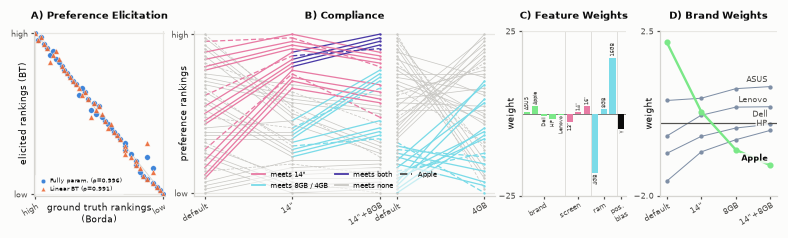

In [132]:
MODEL = ("qwen", "32")

# --- what each panel shows
BORDA_CONTRACT = "none"            # the run panel 1 compares Borda and BT on
PATH_A = ["none", "screen=14-inch", "ram=8GB+screen=14-inch"]
PATH_B = ["none", "ram=4GB"]       # second flow in panel 2, right of PATH_A; e.g. add "ram=4GB+screen=14-inch" for qwen-32B / 72B
WEIGHTS_CONTRACT = "none"          # the run panel 4 shows the weights of
APPLE_CONTRACTS = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
RANK_BY = "utility"                # "utility" (additive BT, as F1) or "wins" (head-to-head, as F1w)
SHOW_GAMMA = True
TICK_ANGLE = 30                    # all panels: x tick label angle (0 = flat, 90 = vertical)
BAR_VALUES = False                 # numbers on the weight bars (panel 3); fits only on a wide figure
BAR_LABELS = True                  # name each weight bar (Apple, 14", 4GB, ...) at its outer end (panel 3)
LABELS = False                     # laptop names at the right end of the panel 2 lines

# --- text
# one entry per panel, left to right ("" = none): Borda vs BT | both paths | weights | brands
SUBTITLES = ["Preference Elicitation", "Compliance", "Feature Weights", "Brand Weights"]
XLABELS = ["ground truth rankings (Borda)", "", "", ""]
YLABELS = ["elicited rankings (BT)", "preference rankings", "weight", "weight"]
RANK_TICKS = ("high", "low")       # panels 1-2: the rank-axis ends (rank 1 and rank 45)
# None = no legend, "auto" = the default texts, or a list of texts (replaces the defaults in order)
LEGENDS = {1: ["Fully param.", "Linear BT"], 2: "auto"}
CONTRACT_NAMES = {"none": "default", "14-inch": '14"', "13-inch": '13"', "16-inch": '16"'}   # x-axis names

# --- layout
WIDTHS = [20, 46, 16, 18]          # each panel's share of the width, in percent (must sum to 100)
GAP = 0.01                         # space between the panels
FLOW_GAP = 0.2                     # panel 2: space between the two flows, in x steps (1 = one contract step)
PANEL_LABELS = ["A)", "B)", "C)", "D)"]   # None = no letters
FIGSIZE = (7, 2)                   # inches
FONT_SIZE = 6                     # base font size; every text and line width scales with it

# --- colours (any key left out keeps its default from DEFAULT_COLORS)
COLORS = {
    "screen": "#e87ba4",        # pink: feature colour, and "meets the screen requirement"
    "ram": "#7BDBE8",           # blue: feature colour, and "meets the RAM requirement"
    "brand": "#7BE888",         # green: feature colour, and Apple's line in panel 5
    "both": "#4a3aa7",          # panels 2-3: meets both requirements
    "none": "#c9c8c4",          # panels 2-3: meets none
    "gamma": "#0b0b0b",         # panel 4: the positional-bias bar
    "full_bt": "#2a78d6",       # panel 1: fully parametrised BT
    "linear_bt": "#eb6834",     # panel 1: linear (additive) BT
    "other_brands": "#7f8fa6",  # panel 5: the four brands that are not Apple
}
SAVE = True
fig = make_summary(MODEL, SUBTITLES, XLABELS, YLABELS, LEGENDS, WIDTHS, CONTRACT_NAMES,
                   borda_contract=BORDA_CONTRACT, path_a=make_path(PATH_A), path_b=make_path(PATH_B),
                   weights_contract=WEIGHTS_CONTRACT, apple_contracts=APPLE_CONTRACTS, rank_by=RANK_BY,
                   show_gamma=SHOW_GAMMA, labels=LABELS, colors=COLORS, bar_values=BAR_VALUES, bar_labels=BAR_LABELS,
                   rank_ticks=RANK_TICKS, gap=GAP, tick_angle=TICK_ANGLE, flow_gap=FLOW_GAP, panel_labels=PANEL_LABELS,
                   figsize=FIGSIZE, font_size=FONT_SIZE, save=SAVE)
fig.savefig(os.path.join(FIGDIR, f"summary_{name(MODEL)}.pdf"), facecolor=SURFACE)   # vector copy for the paper
plt.show()